# Sparse Autoencoders for Interpretability

Transformers are remarkable but opaque. Individual neurons inside a model are rarely *monosemantic*: they don't correspond to a single, human-interpretable concept. Instead, models pack many more features than they have neurons, representing them as combinations of neuron activations. This is called **superposition**.

If we want to interpret what's happening inside a model, we need some way to unpack these superposed features. One of the most useful tools for this is the **sparse autoencoder** (SAE): a second, much wider network trained to reconstruct a layer's activations from a sparse, higher-dimensional representation. In the hidden layer of the SAE, we hope that each neuron is monosemantic.

In this lecture, we'll build a small SAE from scratch, train it on sentence embeddings, and use a language model to automatically interpret the features it discovers.

In [1]:
import re
from collections import defaultdict, namedtuple
from typing import Optional

import pandas as pd
import seaborn as sns
import torch
from torch import nn, Tensor
import torch.nn.functional as F
from tqdm.notebook import tqdm

## The TopK sparse autoencoder

A sparse autoencoder has the usual encoder/decoder structure, but with two distinctive twists:

1. The hidden layer is *wider* than the input — often by a factor of 2-64$\times$. The intuition is that if the input has dimension $d$, the true number of features represented in superposition could be much larger, but only a few are present in any given input.
2. The hidden activations are forced to be **sparse**: most of them should be zero for any given input.

There are several ways to enforce sparsity (an L1 penalty is common). We'll use one of the simplest and most effective: the **TopK** SAE. For each input, we keep only the $k$ largest pre-activation values and zero out the rest.

In [2]:
SAEOutput = namedtuple("SAEOutput", ["x_hat", "h_sparse", "h"])


class TopKSAE(nn.Module):
    def __init__(self, embed_dim: int, expansion_factor: float, k: int):
        super().__init__()
        self.k = k
        self.h_dim = int(embed_dim * expansion_factor)
        self.encoder = nn.Linear(embed_dim, self.h_dim)
        self.decoder = nn.Linear(self.h_dim, embed_dim)

    def forward(self, x: Tensor) -> SAEOutput:
        h = self.encoder(x)
        topk, _ = torch.topk(h, self.k, dim=1)
        mask = h >= topk[:, [-1]]
        h_sparse = h * mask.float()
        x_hat = self.decoder(h_sparse)
        return SAEOutput(x_hat, h_sparse, h)

### Dead latents and the auxiliary loss

TopK selection has a subtle but serious side effect. On any given input, only the $k$ highest pre-activations contribute to the reconstruction $\hat{x}$. The rest get multiplied by zero:

$$\hat{x} = W_{dec} \, \bigl(h \odot \mathbb{1}[h \geq h_{(k)}]\bigr)$$

When we backprop, the gradient of the MSE loss w.r.t. a latent's activation is zero if that latent was masked out. Since $h = W_{enc} x + b$, the gradient flowing into the encoder weights for that latent is *also* zero. In other words, **a latent that fails to make the top-$k$ on every input in a batch receives no gradient signal at all**. If a latent is unlucky at initialization and loses the top-$k$ race early on, there is nothing to pull it back into the competition — it stays **dead** forever, and we lose that capacity.

To fight this, we add an **auxiliary loss** (Gao et al., 2024, a variant of the "ghost grads" trick). We track which latents have fired in the last epoch and, for the dead ones, ask them to reconstruct the *residual error* $x - \hat{x}$ using their own top-$k_\text{aux}$. This side-task gives each dead latent a non-zero gradient path back to the encoder, even though the main TopK mask would otherwise silence it.

In [3]:
SAELossOutput = namedtuple("SAELossOutput", ["total_loss", "mse_loss", "aux_loss"])


class TopKSAELoss(nn.Module):
    def __init__(
        self,
        n_latents: int,
        k_active: int,
        samples_per_epoch: int,
        k_aux: Optional[int] = None,
        aux_scale: float = 1 / 32,
    ):
        super().__init__()
        self.n_latents = n_latents
        self.k_active = k_active
        self.k_aux = k_aux if k_aux is not None else 2 * k_active
        self.aux_scale = aux_scale
        self.samples_per_epoch = samples_per_epoch

        self.register_buffer("latent_activations", torch.zeros(n_latents))
        self.samples_processed = 0

    def update_dead_latents(self, h_sparse: Tensor):
        self.latent_activations += (h_sparse.abs().sum(dim=0) > 0).float()
        self.samples_processed += h_sparse.shape[0]
        if self.samples_processed >= self.samples_per_epoch:
            self.dead_latents = self.latent_activations == 0
            self.latent_activations.zero_()
            self.samples_processed = 0

    def forward(self, x, sae_output: SAEOutput, sae: TopKSAE) -> SAELossOutput:
        x_hat, h_sparse, _ = sae_output

        mse_loss = F.mse_loss(x_hat, x)
        self.update_dead_latents(h_sparse)
        aux_loss = torch.tensor(0.0, device=x.device)

        if hasattr(self, "dead_latents") and self.dead_latents.any():
            e = x - x_hat
            z = torch.zeros_like(h_sparse)
            z[:, self.dead_latents] = sae.encoder(x)[:, self.dead_latents]
            k = min(self.k_aux, self.dead_latents.sum().item(), z.size(1))

            if k > 0:
                values, _ = torch.topk(z[:, self.dead_latents], k, dim=1)
                kth_values = values[:, -1].unsqueeze(1)
                mask = (z[:, self.dead_latents] >= kth_values).float()
                z[:, self.dead_latents] *= mask

            e_hat = sae.decoder(z)
            aux_loss = F.mse_loss(e_hat, e)

        total_loss = mse_loss + self.aux_scale * aux_loss
        return SAELossOutput(total_loss, mse_loss, aux_loss)

### Training and inference

With the model and loss defined, the rest of the training loop is standard: batch the data, forward pass, backprop, step the optimizer. The `infer_sparse` function runs the trained SAE in inference mode over the full dataset to collect sparse activations.

In [4]:
def train_sae(
    X: Tensor,
    expansion_factor: float,
    k: int,
    num_training_steps: int = 20000,
    lr: float = 1e-4,
    batch_size: int = 2048,
    device: str = "cpu",
    log_every: int = 100,
) -> tuple[TopKSAE, pd.DataFrame]:
    samples_per_epoch, embed_dim = X.size()
    sae = TopKSAE(embed_dim, expansion_factor, k)
    sae_loss = TopKSAELoss(sae.h_dim, k, samples_per_epoch)
    optimizer = torch.optim.AdamW(sae.parameters(), lr=lr)

    total_loss_log, mse_loss_log, aux_loss_log, steps_log = [], [], [], []

    sae.train()
    sae.to(device)
    sae_loss.to(device)
    for step in tqdm(range(num_training_steps)):
        start = (step * batch_size) % samples_per_epoch
        stop = start + batch_size
        if stop < samples_per_epoch:
            batch = X[start:stop].to(device)
        else:
            batch = torch.cat([X[start:], X[: stop % samples_per_epoch]]).to(device)

        optimizer.zero_grad()
        sae_output = sae(batch)
        total_loss, mse_loss, aux_loss = sae_loss(batch, sae_output, sae)

        total_loss.backward()
        optimizer.step()

        if step % log_every == 0:
            total_loss_log.append(total_loss.cpu().item())
            mse_loss_log.append(mse_loss.cpu().item())
            aux_loss_log.append(aux_loss.cpu().item())
            steps_log.append(step)

    sae.cpu()

    return sae, pd.DataFrame({
        "step": steps_log,
        "total_loss": total_loss_log,
        "mse_loss": mse_loss_log,
        "aux_loss": aux_loss_log,
    })


def infer_sparse(X, sae, batch_size: int = 2048, device: str = "cpu") -> Tensor:
    n = X.size(0)
    sae.eval()
    sae.to(device)

    H = []
    for i in range(0, n, batch_size):
        with torch.no_grad():
            batch = X[i : i + batch_size].to(device)
            _, h_sparse, _ = sae(batch)
        H.append(h_sparse.cpu())
    return torch.cat(H)

## Training on news embeddings

To have something to interpret, we need a dataset of activations. For simplicity, we'll use sentence embeddings of news articles as our "activations." The same SAE approach works on hidden states pulled from inside a real LLM — the only thing that changes is the input distribution.

In [5]:
from datasets import load_dataset
from sentence_transformers import SentenceTransformer

st_model = SentenceTransformer("all-MiniLM-l6-v2")

ds = load_dataset("fancyzhx/ag_news", split="train")
df = (
    ds.to_pandas()
    .rename(columns={"text": "body"})
    .sample(75000, random_state=0)
    .reset_index(drop=True)
)
df.head()

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-l6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


README.md: 0.00B [00:00, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/18.6M [00:00<?, ?B/s]

data/test-00000-of-00001.parquet:   0%|          | 0.00/1.23M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/120000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/7600 [00:00<?, ? examples/s]

,body,label
0,First class to the moon London - British airli...,3
1,Amazon #39;s Holiday Pi Leave it to Amazon.com...,3
2,Will historic flight launch space tourism? Reg...,3
3,Thais Drop Peace Bombs On Muslims (CBS) Millio...,0
4,U.S. Economy Grows at Slower Pace Than Expecte...,2


In [6]:
df.value_counts("label")

label
1    18828
2    18758
3    18728
0    18686
Name: count, dtype: int64

We embed every article with the sentence transformer to get a $(N, 384)$ tensor of embeddings.

In [7]:
X = st_model.encode(df.body.tolist(), convert_to_tensor=True, show_progress_bar=True)
X.shape

Batches:   0%|          | 0/2344 [00:00<?, ?it/s]

torch.Size([75000, 384])

Now we train. We use an expansion factor of 2 (so the hidden layer has $2 \times 384 = 768$ latents) and keep only the top 16 latents active on each input. That means each input is represented by just 16 non-zero activations out of 768.

In [8]:
sae, logs = train_sae(
    X.clone(), expansion_factor=2, k=16, device="cuda", num_training_steps=25000
)

  0%|          | 0/25000 [00:00<?, ?it/s]

A quick look at the training curves:

<Axes: xlabel='step', ylabel='value'>

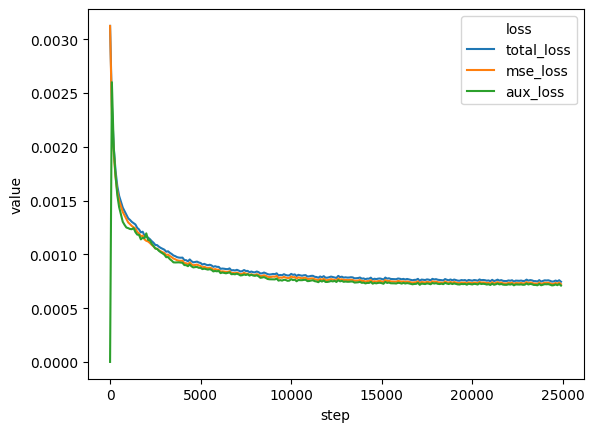

In [9]:
sns.lineplot(
    data=logs.melt(["step"], var_name="loss"),
    x="step",
    y="value",
    hue="loss",
)

## Inspecting sparse features

With a trained SAE, we can get sparse activations for every article in our dataset. The tensor `H` has shape `(N, h_dim)`, where each row is the sparse representation of a single article.

In [10]:
H = infer_sparse(X.clone(), sae, device="cuda")
H.shape

torch.Size([75000, 768])

For each feature (column of `H`), we want to know which articles activate it most strongly. `argsort` along each column, with `-H` to sort descending, gives us the indices of the top-activating examples for every feature.

In [11]:
H_idx_sorted = torch.argsort(-H, dim=0)
H_idx_sorted

tensor([[58798, 71873, 22649,  ..., 12090, 37007, 39361],
        [ 3540, 30305, 50868,  ..., 20904,  3214,   609],
        [73865,  7084, 34189,  ..., 73178,  2870,  7990],
        ...,
        [25153, 25355, 25408,  ..., 25064, 25339, 25211],
        [25152, 25354, 25407,  ..., 25063, 25338, 25210],
        [25151, 25353, 25406,  ..., 25062, 25337, 25209]])

How many of our latents are dead — never fire on any input in our dataset?

In [12]:
(H.sum(dim=0) == 0).sum()

tensor(6)

Here are the three articles that most strongly activate feature 1. Look at them and see if you can tell what this feature has picked up on.

In [13]:
df.iloc[H_idx_sorted[:3, 1].tolist()]

,body,label
71873,"Indiana, Ole Miss, BYU Dismiss Coaches Gerry D...",1
30305,Coach to clash with former point guard Geno Au...,1
7084,El Salvador fires national soccer team coach a...,1


## Auto-interpretation of features

Manually reading top-activating examples works for a handful of features, but it doesn't scale. With hundreds or thousands of active features, we need an automated way to describe what each one captures.

The standard approach is **auto-interpretation** (or *feature verbalization*): show an LLM the top-activating examples for a feature and ask it to describe what they have in common. To make the task easier, we also show the model *negative* examples — articles where the feature doesn't fire — as a contrast set.

### Sampling activating examples

In [14]:
def get_positive_samples(
    dataframe: pd.DataFrame,
    sorted_feature_activations: Tensor,
    feature_activations: Tensor,
    num_samples: int = 5,
    num_features: int = 5,
) -> dict:
    positive_samples = defaultdict(list)
    for i in range(num_features):
        for j in range(num_samples):
            index = sorted_feature_activations[j, i].item()
            activation = feature_activations[index, i]
            if activation > 0:
                positive_samples[i].append({
                    "index": index,
                    "text": dataframe.iloc[index]["body"],
                    "activation": round(activation.item(), 2),
                })
    return positive_samples


def get_negative_samples(
    dataframe: pd.DataFrame,
    feature_activations: Tensor,
    num_samples: int = 5,
    num_features: int = 5,
) -> dict:
    negative_samples = defaultdict(list)
    for i in range(num_features):
        zero_act_idx = torch.argwhere(feature_activations[:, i] == 0).squeeze()
        random_idx = torch.randint(
            zero_act_idx.size(0),
            size=[min(num_samples, zero_act_idx.size(0))],
        )
        for idx in zero_act_idx[random_idx]:
            negative_samples[i].append({
                "index": idx.item(),
                "text": dataframe.iloc[idx.item()]["body"],
                "activation": 0,
            })
    return negative_samples


def get_nonzero_samples(
    dataframe: pd.DataFrame,
    feature_activations: Tensor,
    num_samples: int = 5,
    num_features: int = 5,
) -> dict:
    samples = defaultdict(list)
    for i in range(num_features):
        nz_idx = torch.argwhere(feature_activations[:, i]).squeeze()
        random_idx = torch.randint(
            nz_idx.size(0),
            size=[min(num_samples, nz_idx.size(0))],
        )
        for idx in nz_idx[random_idx]:
            samples[i].append({
                "index": idx.item(),
                "text": dataframe.iloc[idx.item()]["body"],
                "activation": round(feature_activations[idx.item(), i].item(), 2),
            })
    return samples

In [15]:
num_features = 5
num_samples = 10
positive_samples = get_positive_samples(df, H_idx_sorted, H, num_samples=num_samples, num_features=num_features)
negative_samples = get_negative_samples(df, H, num_samples=num_samples, num_features=num_features)
nonzero_samples = get_nonzero_samples(df, H, num_samples=num_samples, num_features=num_features)

In [16]:
positive_samples[0]

[{'index': 58798,
  'text': 'New strike action hits Bangladesh Bangladeshi businesses, schools and shops are closed, as a second general strike in a week takes place. The strike is in protest at a grenade attack a week ago on a rally addressed by the opposition Awami ',
  'activation': 0.56},
 {'index': 3540,
  'text': 'S.Korea Civil Servants Strike Over Right to Strike  SEOUL (Reuters) - South Korean public sector workers  launched an unprecedented strike Monday, setting them on a  collision course with the government of President Roh Moo-hyun,  which has vowed a tough line on what it labels an illegal  action.',
  'activation': 0.55},
 {'index': 73865,
  'text': 'Ukraine opposition calls strike Ukrainian opposition leader Viktor Yushchenko calls for a general strike as he rejects the presidential poll result.',
  'activation': 0.53},
 {'index': 31865,
  'text': 'Public Service Workers Strike in South Africa A one-day nationwide strike of civil service workers in South Africa has brou

In [17]:
negative_samples[0]

[{'index': 64015,
  'text': 'Vladimir Putin comes out for dual citizenship between Russia and &lt;b&gt;...&lt;/b&gt; Russian President Vladimir Putin asked State Duma and Federation Council Speakers Boris Gryzlov and Sergei Mironov to begin consultations with Ukrainian parliamentarians on the introduction of dual citizenship between Russia and Ukraine.',
  'activation': 0},
 {'index': 62726,
  'text': 'U.S. Military Names More Enemy Combatants (AP) AP - U.S. military review tribunals have ordered five more prisoners to remain held as enemy combatants in Guantanamo Bay, Cuba, a Navy official said Saturday.',
  'activation': 0},
 {'index': 61113,
  'text': 'Low-Carb Diet Craze Hits Plateau There was a time when the low-carbohydrate Atkins and South Beach diets were sending tsunamis through the financial world. Riding swelling demand up was MGP Ingredients (Nasdaq: MGPI) -- formerly ',
  'activation': 0},
 {'index': 49758,
  'text': 'US Air, Pilots to Reopen Concession Talks US Airways (U

### Generating descriptions with an LLM

We'll use [Qwen2.5-1.5B-Instruct](https://huggingface.co/Qwen/Qwen2.5-1.5B-Instruct) as our interpreter. It's small enough to run quickly over hundreds of prompts but still good enough to summarize what a handful of texts have in common.

In [18]:
from transformers import AutoModelForCausalLM, AutoTokenizer

interp_model_name = "Qwen/Qwen2.5-1.5B-Instruct"
interp_tokenizer = AutoTokenizer.from_pretrained(interp_model_name)
interp_model = AutoModelForCausalLM.from_pretrained(
    interp_model_name,
    torch_dtype=torch.bfloat16,
    device_map="auto",
)
interp_model.eval()

config.json:   0%|          | 0.00/660 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

`torch_dtype` is deprecated! Use `dtype` instead!


model.safetensors:   0%|          | 0.00/3.09G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/242 [00:00<?, ?B/s]

Qwen2ForCausalLM(
  (model): Qwen2Model(
    (embed_tokens): Embedding(151936, 1536)
    (layers): ModuleList(
      (0-27): 28 x Qwen2DecoderLayer(
        (self_attn): Qwen2Attention(
          (q_proj): Linear(in_features=1536, out_features=1536, bias=True)
          (k_proj): Linear(in_features=1536, out_features=256, bias=True)
          (v_proj): Linear(in_features=1536, out_features=256, bias=True)
          (o_proj): Linear(in_features=1536, out_features=1536, bias=False)
        )
        (mlp): Qwen2MLP(
          (gate_proj): Linear(in_features=1536, out_features=8960, bias=False)
          (up_proj): Linear(in_features=1536, out_features=8960, bias=False)
          (down_proj): Linear(in_features=8960, out_features=1536, bias=False)
          (act_fn): SiLUActivation()
        )
        (input_layernorm): Qwen2RMSNorm((1536,), eps=1e-06)
        (post_attention_layernorm): Qwen2RMSNorm((1536,), eps=1e-06)
      )
    )
    (norm): Qwen2RMSNorm((1536,), eps=1e-06)
    (rotar

A small helper that applies Qwen's chat template, generates a response, and returns just the decoded assistant turn.

In [ ]:
def generate_response(prompt: str, max_new_tokens: int = 64) -> str:
    messages = [{"role": "user", "content": prompt}]
    inputs = interp_tokenizer.apply_chat_template(
        messages,
        return_tensors="pt",
        return_dict=True,
        add_generation_prompt=True,
    ).to(interp_model.device)

    with torch.no_grad():
        output = interp_model.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
            do_sample=False,
            pad_token_id=interp_tokenizer.eos_token_id,
        )
    prompt_len = inputs["input_ids"].shape[-1]
    return interp_tokenizer.decode(
        output[0][prompt_len:], skip_special_tokens=True
    ).strip()

The prompt asks the LLM to find what's shared across the positive samples but absent from the negative samples, and to describe it in a handful of words.

In [20]:
interpreter_template = (
    "Your job is to interpret the role of a neuron in a neural network.\n"
    "You will see two types of text:\n"
    "\t1. Positive samples, which are texts that activate that neuron the most in our data.\n"
    "\t2. Negative samples, which are texts that do not activate that neuron at all.\n"
    "Using these positive and negative examples, determine what characteristics are "
    "present in the positive samples but entirely absent in the negative samples.\n"
    "These characteristics can range from simple (e.g. the inclusion of a word, phrase, or "
    "special character) to complex (e.g. discussion of certain subject matter or topics, or "
    "stylistic or syntactic features). Use Occam's razor: do not propose a more complex "
    "explanation when a simpler one would suffice.\n\n"
    "Your final answer must be a SHORT description of the neuron in 5 to 10 words. "
    "Do NOT exceed 10 words. Do NOT include commentary, justification, or any other text.\n\n"
    "Positive samples:\n{positive}\n"
    "Negative samples:\n{negative}\n"
    "Description:"
)

pos_template = "Activation: {activation}\nText: {text}\n"
neg_template = "Activation: 0\nText: {text}\n"


In [ ]:
interpretations = {}
for i in tqdm(range(num_features)):
    pos_examples = "\n".join(
        pos_template.format(activation=s["activation"], text=s["text"])
        for s in positive_samples[i]
    )
    neg_examples = "\n".join(
        neg_template.format(text=s["text"])
        for s in negative_samples[i]
    )
    prompt = interpreter_template.format(positive=pos_examples, negative=neg_examples)
    interpretations[i] = generate_response(prompt, max_new_tokens=32)

interpretations

## Validating interpretations

A feature description is only useful if it's *predictive*. A good description should let us look at a new piece of text and decide whether the feature fires on it.

To test this, we show the LLM a feature description and a text, and ask it to rate how strongly the feature is present on a scale from $-1$ (not present at all) to $+1$ (clearly present). If the interpretation is good, these predicted scores should correlate with the actual SAE activations on those texts.

In [ ]:
predictor_template = (
    "You will read a FEATURE DESCRIPTION followed by a short TEXT.\n"
    "Your task is to determine the extent to which the feature described by the "
    "FEATURE DESCRIPTION is present in the TEXT.\n"
    "Respond with a single number between -1 and 1, where\n"
    "\t-1: The feature is NOT present in the TEXT at all,\n"
    "\t 0: Not sure or uncertain,\n"
    "\t 1: The feature is clearly present in the TEXT.\n"
    "The FEATURE DESCRIPTION does not have to account for everything in the TEXT.\n\n"
    "FEATURE DESCRIPTION: {desc}\n"
    "TEXT: {text}\n\n"
    "Your response must be a single number, nothing else. Score:"
)


def parse_score(text: str) -> float:
    match = re.search(r"-?\d*\.?\d+", text)
    if not match:
        return 0.0
    return max(-1.0, min(1.0, float(match.group())))

In [ ]:
scores = {i: {"score": [], "label": []} for i in range(num_features)}
for i in range(num_features):
    print(f"Feature {i}: {interpretations[i]}")
    all_samples = nonzero_samples[i] + negative_samples[i]
    for sample in tqdm(all_samples):
        prompt = predictor_template.format(
            desc=interpretations[i], text=sample["text"]
        )
        response = generate_response(prompt, max_new_tokens=8)
        scores[i]["score"].append(parse_score(response))
        scores[i]["label"].append(1 if sample["activation"] else -1)

Finally, we compute the Pearson correlation between the LLM's predicted scores and the binary activation labels for each feature. Features with a correlation close to 1 have interpretations that the LLM can reliably apply to new text; features with low correlation have descriptions that are too vague or wrong.

In [ ]:
from scipy.stats import pearsonr

for i in range(num_features):
    r = pearsonr(scores[i]["label"], scores[i]["score"]).statistic
    print(f"Feature {i} (r={r:+.3f}): {interpretations[i]}")